In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import logging
import time
import jax
import jax.numpy as jnp
import gc
# Disable JAX preallocation
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


In [2]:
# -----------------------------
# Setup
# -----------------------------
location = "phoenix"
opt_method = "gradient_ascent"

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logging.info("Starting gradient ascent optimization script...")


2026-06-01 10:38:44,426 - INFO - Starting gradient ascent optimization script...


In [3]:

# -----------------------------
# User parameters
# -----------------------------
rotation_angle = 180.0
CE_value = 0.84             # conversion efficiency
NOCT_value = 48.0

thickness_range = np.arange(10.0, 250.0, 10.0) # np.arange(100.0, 320.0, 20.0)
tilt_angles = np.arange(0.0, 50.0, 10.0)

initial_lr_tilt = 10.0
decay_rate_tilt = 0.05
initial_lr_thickness = 50.0
decay_rate_thickness = 0.1
num_steps = 30
min_tilt, max_tilt = 0.0, 90.0
min_thickness, max_thickness = 10.0, 250.0 # 100.0, 300.0

In [4]:
sys.path.append(os.path.join(os.getcwd(), "src"))

In [5]:

# -----------------------------
# Load irradiance and models
# -----------------------------
sys.path.append(os.path.join(os.getcwd(), "src")) # Jupyter notebook version

from SolDi2T.energy_yield.irradiance import trim_irradiance, get_irradiance_data
from SolDi2T.energy_yield.jsc_calculation import JscCalc_jax
from SolDi2T.optics.interpolate_absorption import (
    AbsorptionSurfaceModel,
    load_absorption_surface_model,
    predict_absorption_surface_NN,
)
from SolDi2T.electrics.model_utils import MultiOutputNN, load_model

get_irradiance_data()
# Load irradiance
with open(f"data/irradiance/{location}_irradiance_data.pkl", "rb") as file:
    irradiance = pickle.load(file)

lambda_ = jnp.arange(300, 1201, 1)
lambda_values = irradiance["Irr_spectra_clouds_wavelength"].flatten()
thetasun = irradiance["Data_TMY3"]["Data_TMY3"][:, 6]
phisun = irradiance["Data_TMY3"]["Data_TMY3"][:, 7]
IrradianceDifH = irradiance["Irr_spectra_clouds_diffuse_horizontal"]
IrradianceDirH = irradiance["Irr_spectra_clouds_direct_horizontal"]
TempAmbient = irradiance["Data_TMY3"]["Data_TMY3"][:, 13]

IrradianceDifN = IrradianceDifH / jnp.pi
IrradianceDirN = (jnp.ceil(thetasun) < 90)[:, None] * IrradianceDirH / jnp.abs(
    jnp.cos(jnp.deg2rad(thetasun))
)[:, None]

IdifN = trim_irradiance(lambda_, IrradianceDifN, lambda_values)
IdirN = trim_irradiance(lambda_, IrradianceDirN, lambda_values)

# Load models
loaded_absorption_surface_model, loaded_absorption_surface_params, loaded_absorption_surface_scaler_X = load_absorption_surface_model(
    "data/absorption/absorption_surface_model.pkl"
)
model = MultiOutputNN()
loaded_params, loaded_scaler_X, loaded_scaler_voc, loaded_scaler_jsc, loaded_scaler_ff = load_model(
    "data/electrics/drift_diffusion_nn_model.pkl"
)

# -----------------------------
# Output directory
# -----------------------------
output_dir = os.path.join("data", "results", location)
os.makedirs(output_dir, exist_ok=True)


INFO:2026-06-01 10:38:46,942:jax._src.xla_bridge:924: Unable to initialize backend 'cuda': 
2026-06-01 10:38:46,942 - INFO - Unable to initialize backend 'cuda': 
INFO:2026-06-01 10:38:46,942:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-06-01 10:38:46,942 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-06-01 10:38:46,944:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-06-01 10:38:46,944 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-06-01 10:38:46,944 - WARNING - An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Files already exist. Skipping download.


In [6]:
np.arange(10.0, 250.0, 10.0) 

array([ 10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100., 110.,
       120., 130., 140., 150., 160., 170., 180., 190., 200., 210., 220.,
       230., 240.])

In [7]:
thickness_range[9]

np.float64(100.0)

In [10]:
# -----------------------------
# Energy yield wrapper
# -----------------------------
A = predict_absorption_surface_NN(thickness_range[9],loaded_absorption_surface_model,
                                  loaded_absorption_surface_params,loaded_absorption_surface_scaler_X,)
print('A', A, type(A))
print("A shape:", A.shape)
print("len(A):", len(A)) 

A [[[0.1323884  0.14124991 0.14373225 ... 0.20901974 0.21147302 0.21308117]
  [0.1420275  0.14007133 0.13820162 ... 0.19765383 0.20666277 0.20298198]
  [0.130116   0.13983099 0.1431373  ... 0.21237329 0.21000628 0.20985146]
  ...
  [0.05515874 0.05792365 0.05496874 ... 0.0346469  0.02277177 0.03328276]
  [0.04056545 0.04744578 0.03033755 ... 0.0218495  0.0249829  0.01487355]
  [0.02100192 0.02955069 0.02282781 ... 0.0068611  0.00765242 0.01199478]]] <class 'jaxlib.xla_extension.ArrayImpl'>
A shape: (1, 90, 901)
len(A): 1


[0.1323884  0.14124991 0.14373225 0.14494619 0.16909076 0.16713658
 0.17645007 0.17749844 0.19132952 0.18499379 0.20141369 0.20990282
 0.21110669 0.21887684 0.23040624 0.2274541  0.23928548 0.24106431
 0.24787629 0.25002488 0.27245623 0.25789845 0.26261598 0.26107898
 0.2688614  0.27161783 0.26177064 0.27057344 0.2742857  0.26730543
 0.26791358 0.27013958 0.27705085 0.27461582 0.2671986  0.26985276
 0.26852733 0.27151597 0.28418204 0.27706325 0.27164173 0.27118883
 0.27496657 0.2774178  0.28609306 0.2666428  0.2855254  0.2919019
 0.289206   0.29145008 0.290867   0.28817508 0.29252827 0.29619926
 0.29337412 0.2979701  0.29875785 0.3068985  0.3008367  0.30014727
 0.29051623 0.3101     0.30376804 0.320069   0.32564566 0.33230782
 0.3278784  0.32964712 0.33687735 0.33860973 0.34299973 0.3486554
 0.3537892  0.35715267 0.3576827  0.36042207 0.3725718  0.38235074
 0.37796426 0.38280234 0.37176007 0.38294291 0.38982263 0.3891599
 0.4013385  0.38896522 0.39904878 0.40488395 0.40516624 0.4012194

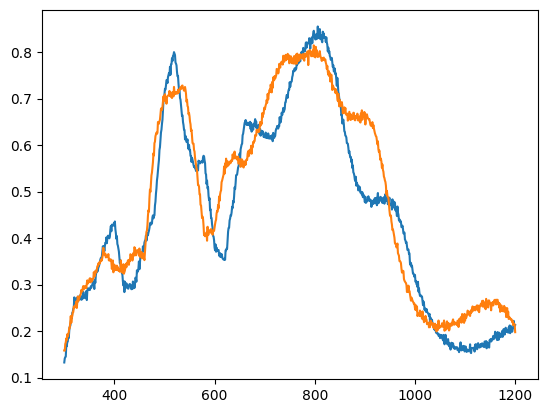

In [16]:
print(A[0, 0]) # does not change over thickness? 
plt.plot(lambda_, A[0, 0])
plt.plot(lambda_, A[0, 30])

In [27]:
print(A[0, 0]) # does change over thickness. could be unitless absorption in active material, A coeff, R coeff, T coeff. 

[0.13547851 0.14765218 0.21044943 0.17531948 0.20015702 0.21785977
 0.26120996 0.19527814 0.24943985 0.14799309 0.2835673  0.26092738
 0.30553347 0.2523271  0.33065912 0.251489   0.26266587 0.2840754
 0.3444159  0.26275748 0.36511773 0.35385528 0.32126746 0.2947384
 0.396021   0.3103673  0.36906135 0.35659632 0.39587033 0.32409424
 0.3621137  0.3495226  0.3901404  0.34781757 0.3701431  0.33599687
 0.3251583  0.36003643 0.35136807 0.34096384 0.31478295 0.32093936
 0.3147253  0.3149248  0.34640554 0.21941471 0.28275424 0.3445339
 0.36889857 0.3753223  0.31267354 0.34086728 0.33235943 0.32453838
 0.32959467 0.353926   0.38393584 0.38456982 0.36702332 0.36040026
 0.31883296 0.39228502 0.35069686 0.39835134 0.41225997 0.3938849
 0.35030735 0.42971194 0.41121876 0.35714552 0.34852242 0.50054836
 0.38487774 0.43365815 0.4556828  0.40876433 0.46855453 0.44646287
 0.44938505 0.36752808 0.4589083  0.45440012 0.4702655  0.5199568
 0.47410542 0.44444415 0.4860153  0.48095813 0.47220522 0.5341356
 